# Plant Disease Prediction

## Importing Dataset

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

In [2]:
TRAIN_PATH = '../dataset/train'
VALID_PATH = '../dataset/valid'

MODEL_PATH = '../model/trained_plant_disease_model.keras'
HISTORY_PATH = '../model/training_hist.json'

## Data Preprocessing

### Training Image preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


## Building Model

In [5]:
cnn = tf.keras.models.Sequential()

### Building Convolution Layer

In [6]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [11]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [12]:
cnn.add(tf.keras.layers.Flatten())

In [13]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))
cnn.add(tf.keras.layers.Dropout(0.4))

In [14]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

### Compiling and Training Phase

In [15]:
cnn.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                   

In [17]:
training_history = cnn.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=5)

Epoch 1/5
2197/2197 [==============================] - 2412s 1s/step - loss: 1.3753 - accuracy: 0.5952 - val_loss: 0.5685 - val_accuracy: 0.8233
Epoch 2/5
2197/2197 [==============================] - 2387s 1s/step - loss: 0.4582 - accuracy: 0.8547 - val_loss: 0.2772 - val_accuracy: 0.9101
Epoch 3/5
2197/2197 [==============================] - 2373s 1s/step - loss: 0.2669 - accuracy: 0.9138 - val_loss: 0.1972 - val_accuracy: 0.9362
Epoch 4/5
2197/2197 [==============================] - 2381s 1s/step - loss: 0.1909 - accuracy: 0.9378 - val_loss: 0.1538 - val_accuracy: 0.9501
Epoch 5/5
2197/2197 [==============================] - 2393s 1s/step - loss: 0.1359 - accuracy: 0.9552 - val_loss: 0.2029 - val_accuracy: 0.9368


## Evaluating Model

In [18]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 [==============================] - 373s 170ms/step - loss: 0.1014 - accuracy: 0.9670
Training accuracy: 0.9670246839523315


In [19]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 [==============================] - 93s 169ms/step - loss: 0.2029 - accuracy: 0.9368
Validation accuracy: 0.9367744326591492


### Saving Model

In [20]:
cnn.save(MODEL_PATH)

In [21]:
training_history.history #Return Dictionary of history

{'loss': [1.3753440380096436,
  0.4581809639930725,
  0.26693016290664673,
  0.1909215748310089,
  0.1358502060174942],
 'accuracy': [0.5952485799789429,
  0.8546980619430542,
  0.9138487577438354,
  0.9378476142883301,
  0.95516037940979],
 'val_loss': [0.5685437917709351,
  0.2772385776042938,
  0.19717152416706085,
  0.15379774570465088,
  0.20286677777767181],
 'val_accuracy': [0.823298454284668,
  0.910141110420227,
  0.9362053275108337,
  0.9500910639762878,
  0.9367744326591492]}

In [22]:
# Recording History in json
with open(HISTORY_PATH,'w') as f:
  json.dump(training_history.history,f)

In [23]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


## Accuracy Visualization

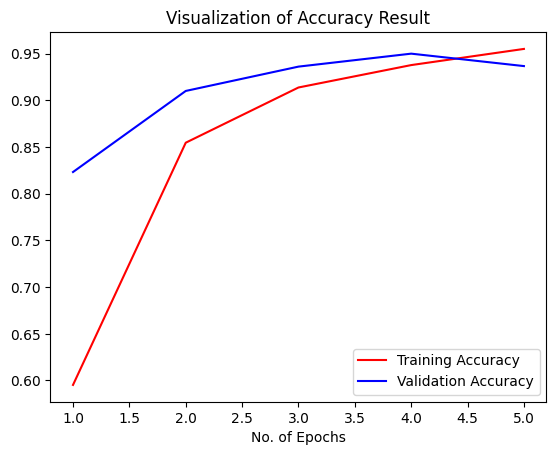

In [24]:
epochs = [i for i in range(1,6)]
plt.plot(
    epochs,
    training_history.history['accuracy'],
    color='red',
    label='Training Accuracy'
)
plt.plot(
    epochs,
    training_history.history['val_accuracy'],
    color='blue',
    label='Validation Accuracy'
)
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [25]:
class_name = validation_set.class_names

In [26]:
test_set = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [27]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 [==============================] - 224s 13ms/step


In [28]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [29]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true, predicted_categories)

In [30]:
# Precision Recall Fscore
print(classification_report(
    Y_true,
    predicted_categories,
    target_names=class_name
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.91      0.93       504
                                 Apple___Black_rot       0.99      0.95      0.97       497
                          Apple___Cedar_apple_rust       0.94      0.98      0.96       440
                                   Apple___healthy       0.95      0.91      0.93       502
                               Blueberry___healthy       0.90      0.98      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.99      0.95      0.97       421
                 Cherry_(including_sour)___healthy       0.97      0.95      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.81      0.88       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.96      0.

### Confusion Matrix Visualization

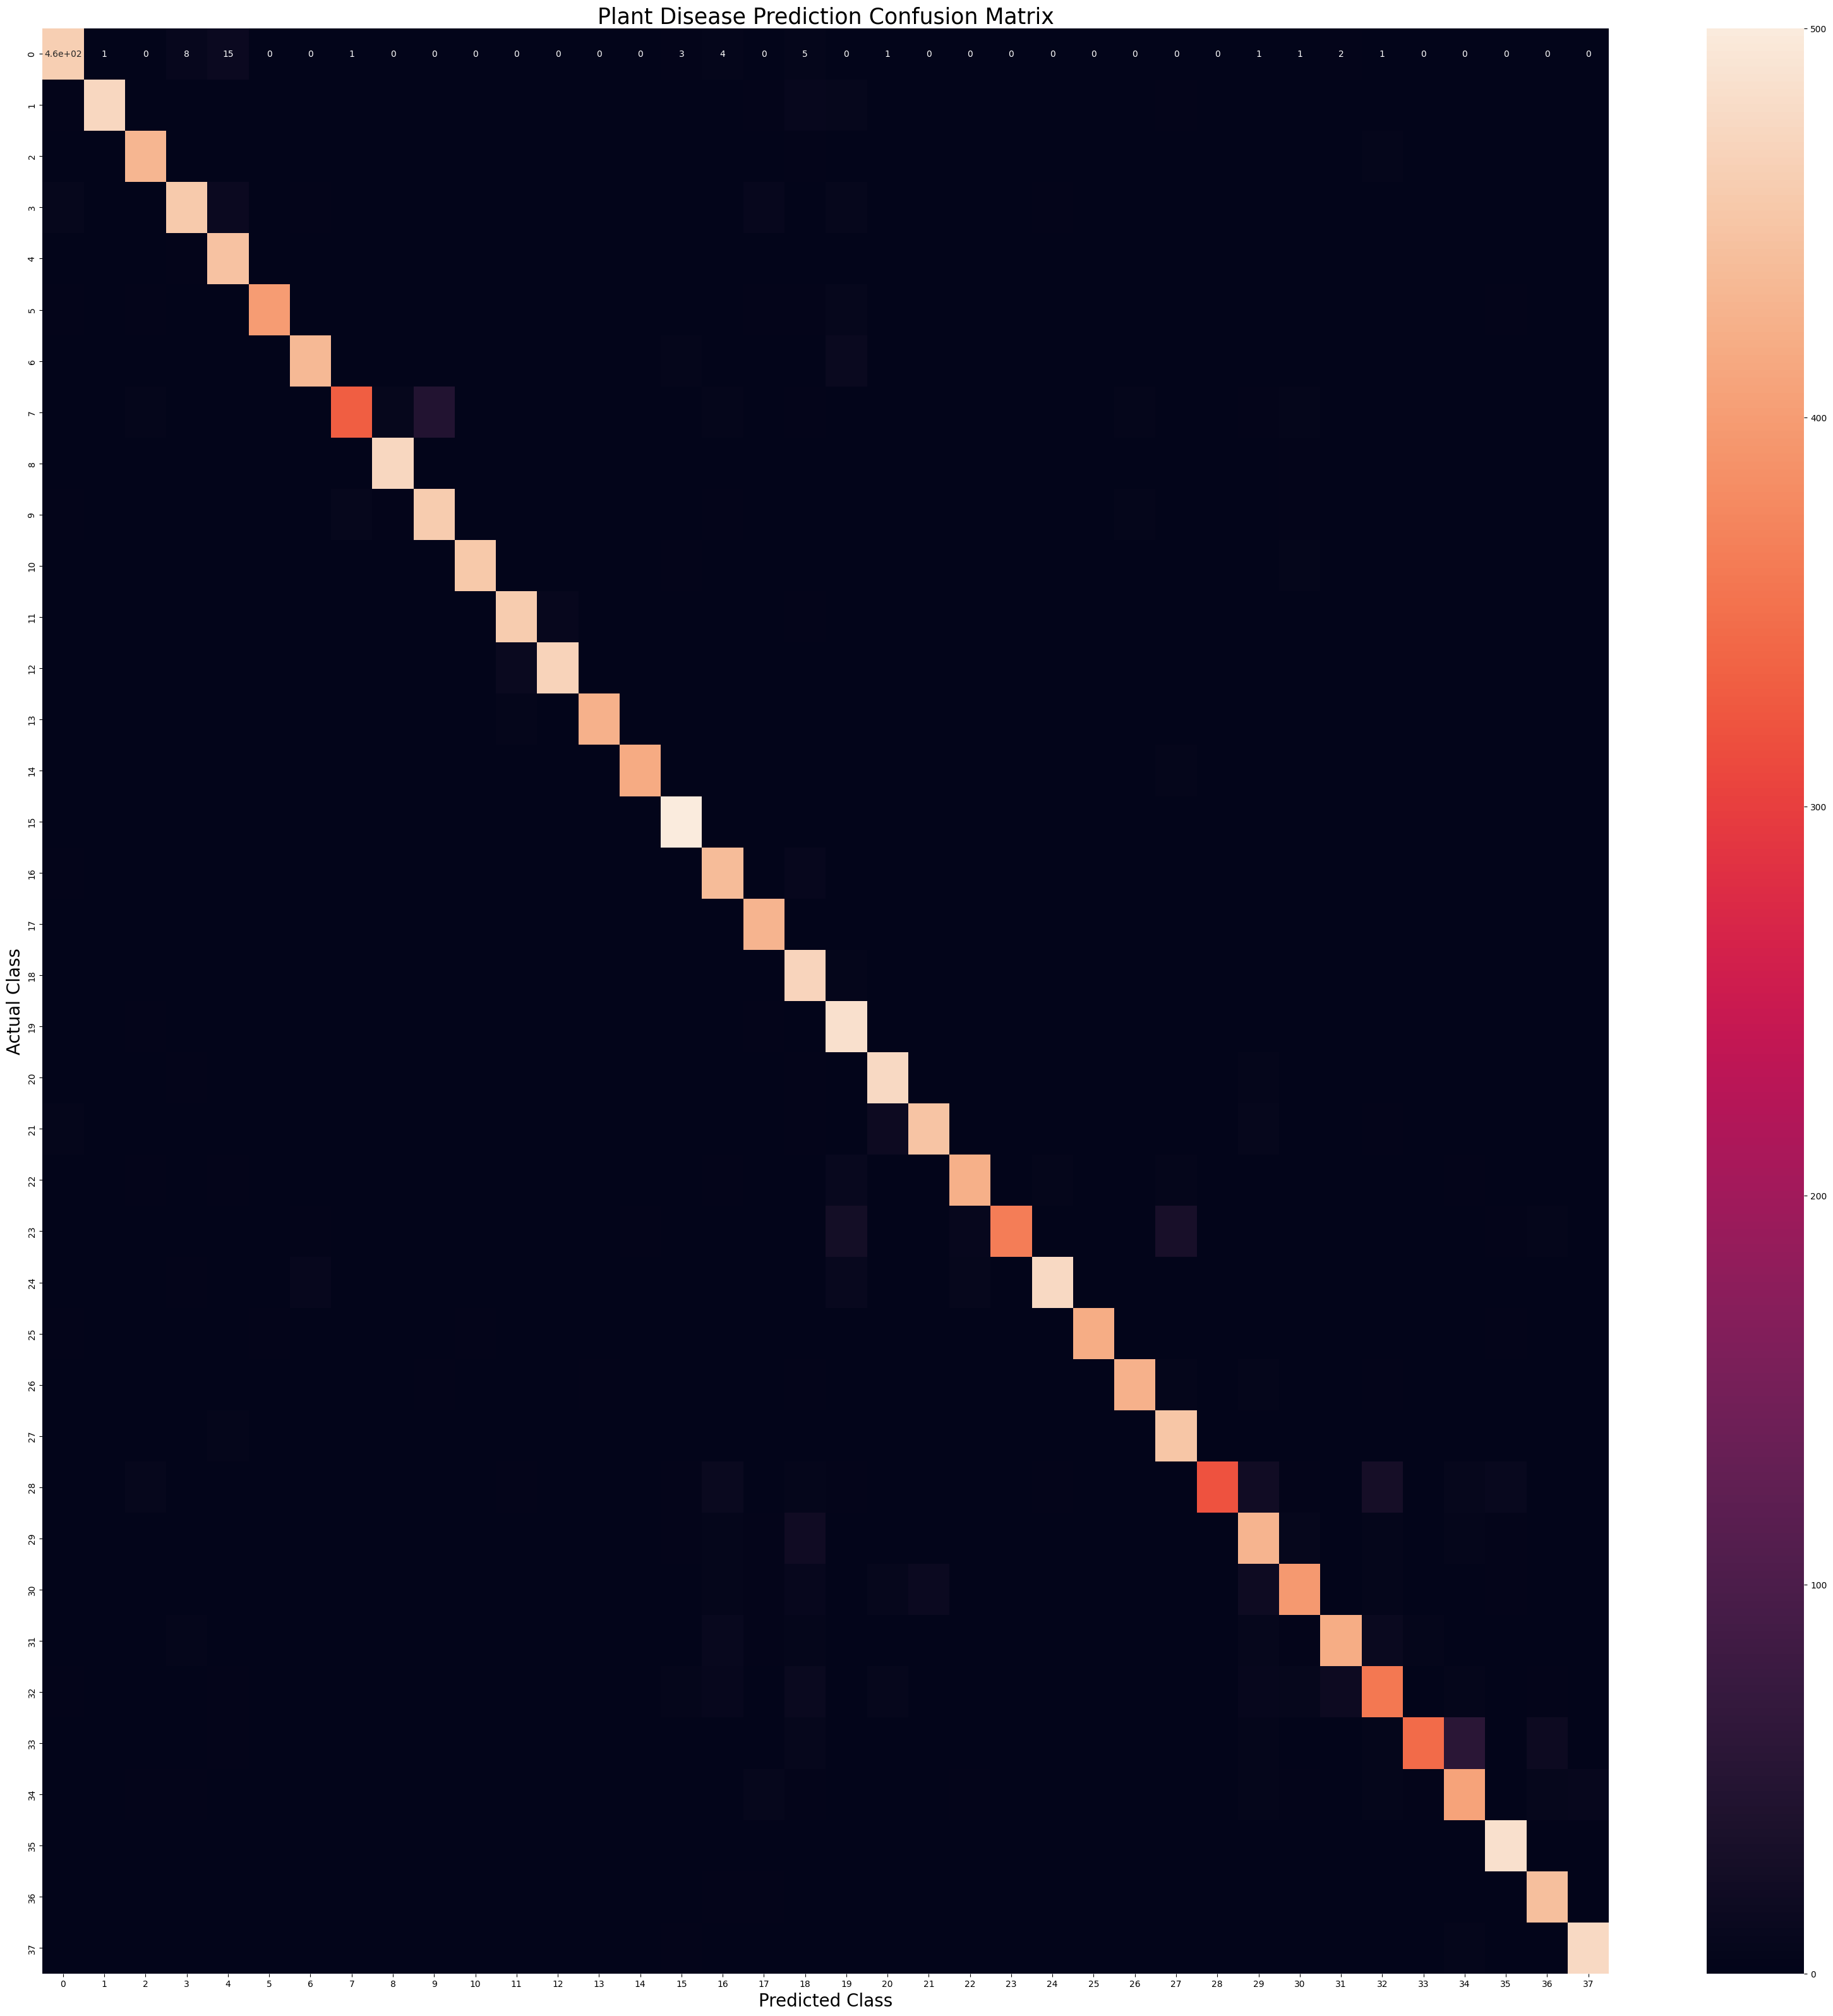

In [31]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,
            annot=True,
            annot_kws={"size": 10}
)

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()